[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Thu May  7 05:34:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%cd /content/drive/MyDrive/Quadrat

[Errno 2] No such file or directory: '/content/drive/MyDrive/Quadrat'
/content


**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip list | grep torch

torch                                    2.10.0+cu128
torchao                                  0.10.0
torchaudio                               2.10.0+cu128
torchcodec                               0.10.0+cu128
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.25.0+cu128


## Install YOLO11 via Ultralytics

In [ ]:
%pip install ultralytics supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="LNfmFg389kG1b6fLf8da")
project = rf.workspace("jfvorano").project("sampleproj-olscq")
version = project.version(2)
dataset = version.download("folder")




loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to SampleProj-2 in folder:: 100%|██████████| 46/46 [00:00<00:00, 7127.64it/s]


## Custom Training

In [ ]:
%cd {HOME}

#!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=250 batch=32 imgsz=640 plots=True patience=40

!yolo task=classify mode=train model=yolov8n-cls.pt data={dataset.location} epochs=10 batch=32 imgsz=640 plots=True patience=40

/content
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/SampleProj-2, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    P_curve.png       train_batch2.jpg
confusion_matrix_normalized.png			    PR_curve.png      val_batch0_labels.jpg
confusion_matrix.png				    R_curve.png       val_batch0_pred.jpg
events.out.tfevents.1743127893.40c329f8d8d3.1867.0  results.csv       val_batch1_labels.jpg
F1_curve.png					    results.png       val_batch1_pred.jpg
labels_correlogram.jpg				    train_batch0.jpg  weights
labels.jpg					    train_batch1.jpg


In [ ]:
%cd /content/drive/MyDrive/COTS_OD

/content/drive/MyDrive/COTS_OD


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


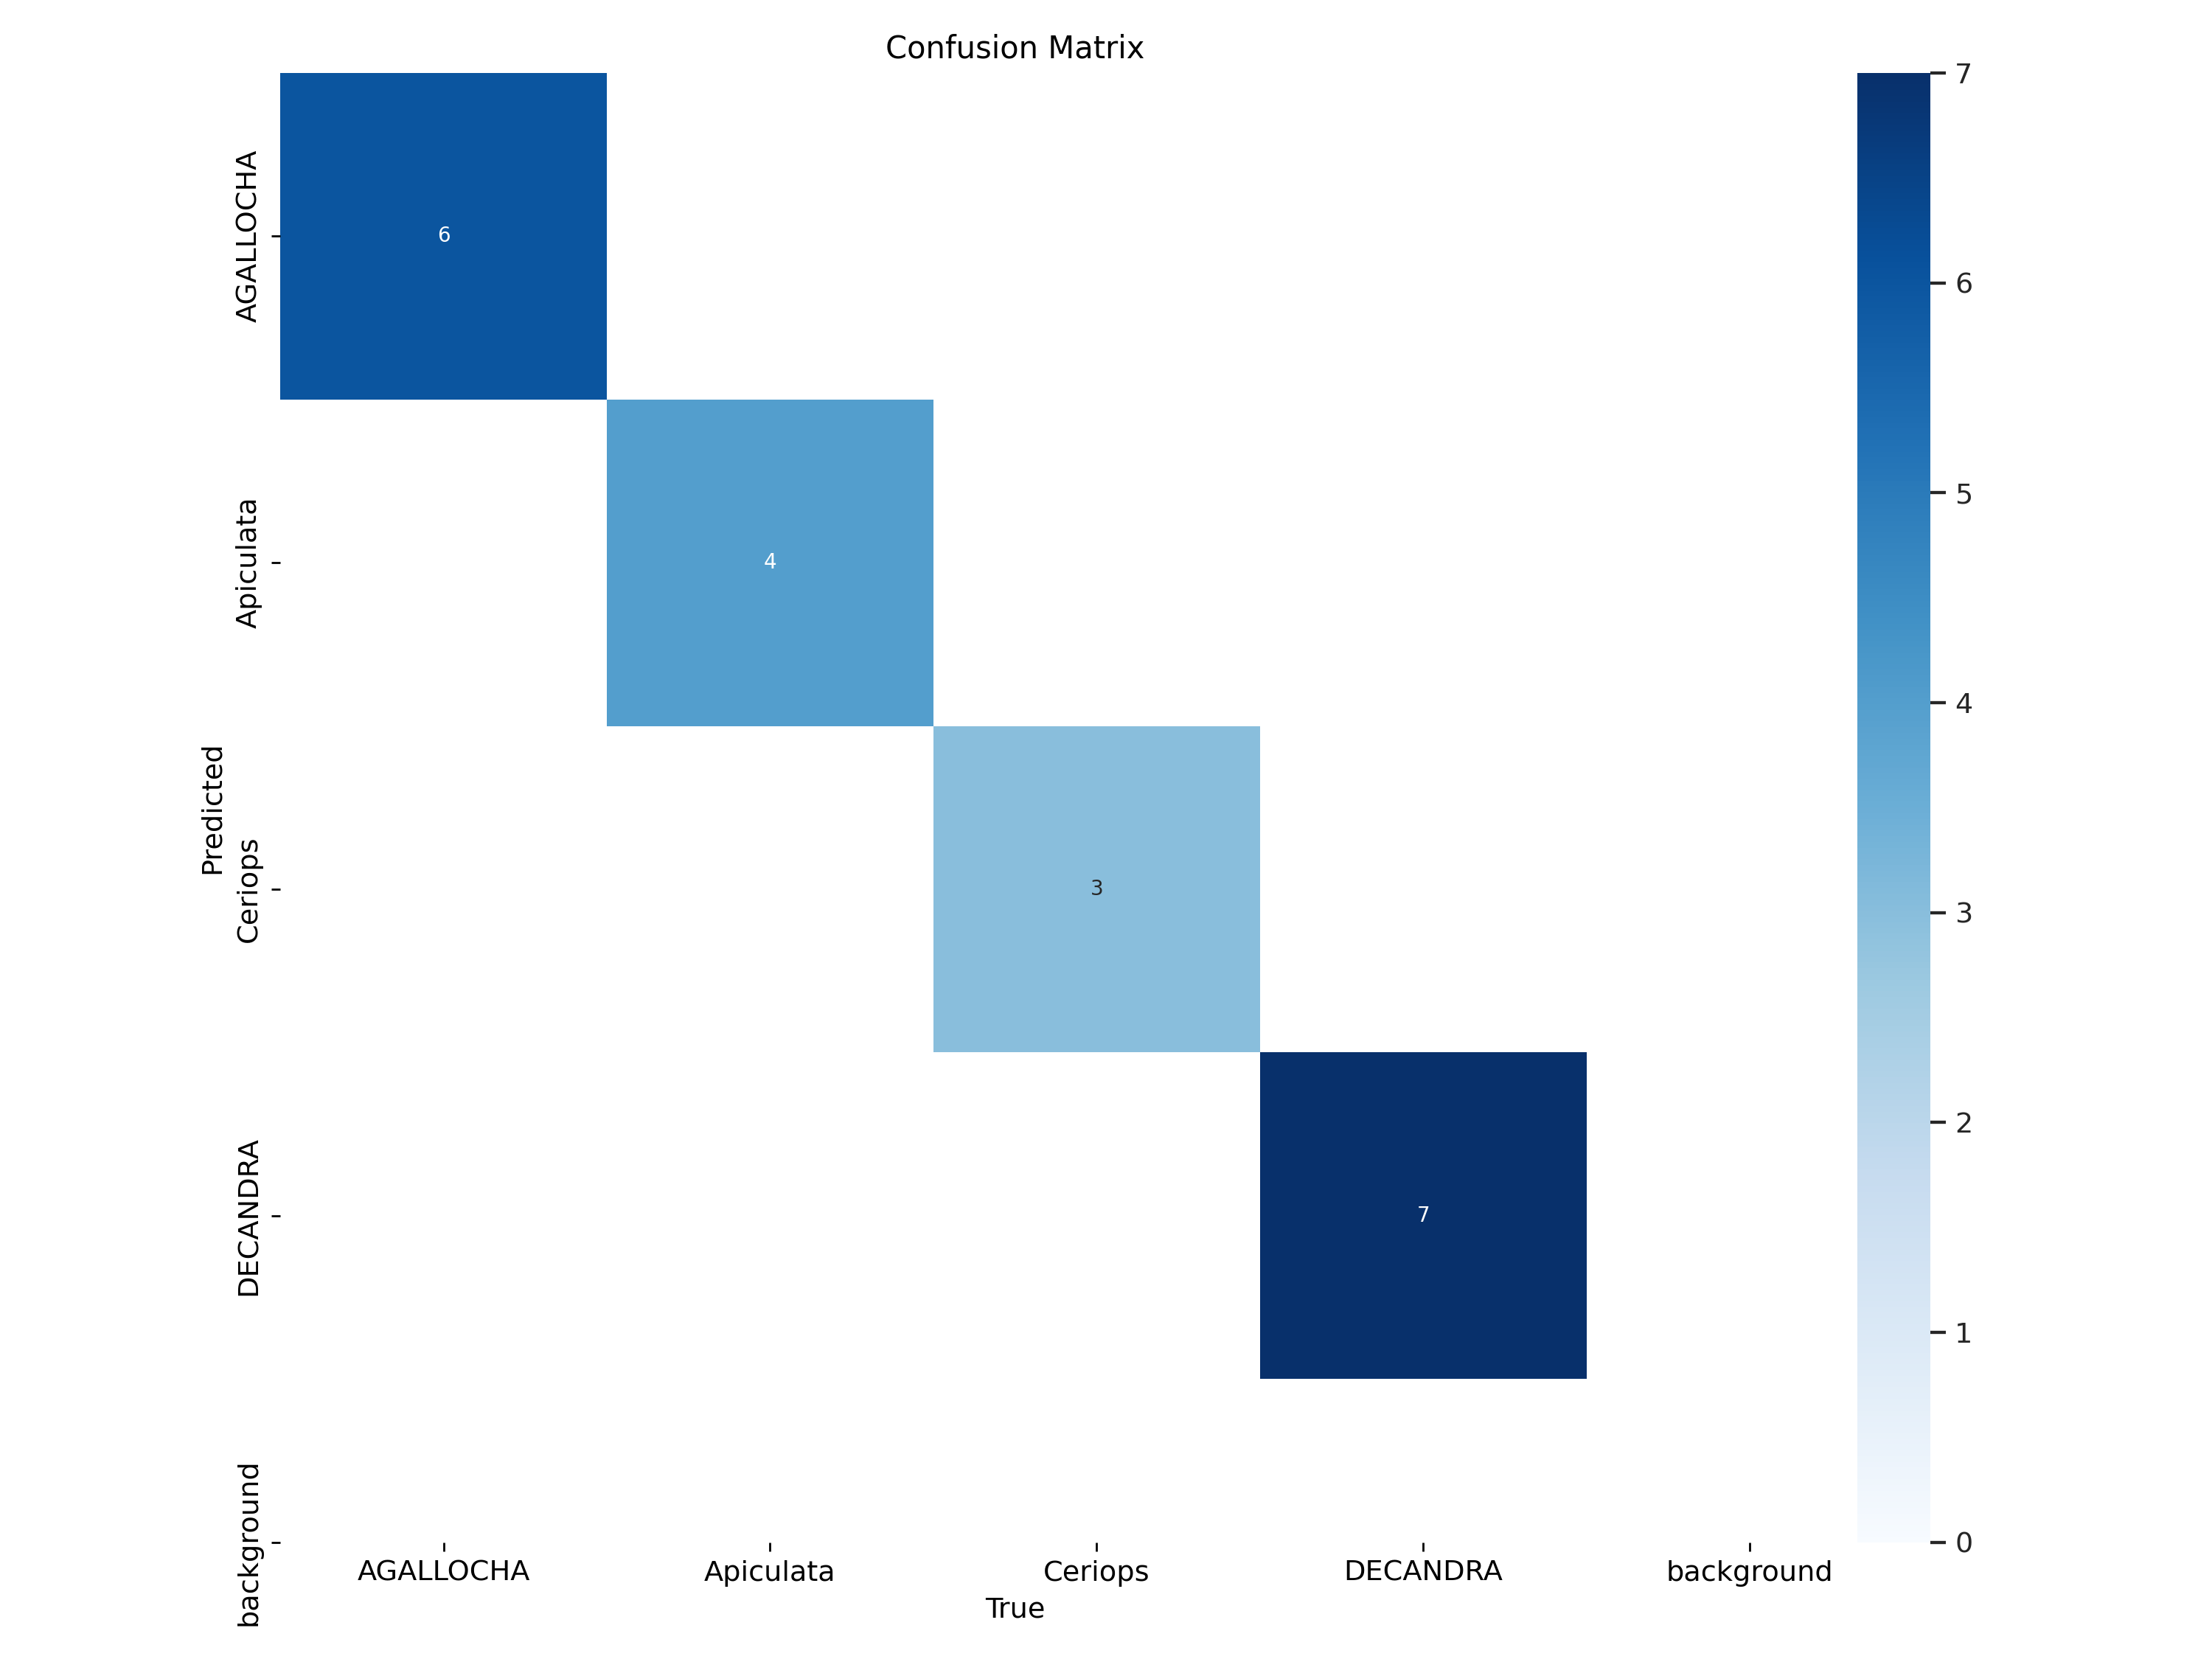

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/classify/train/confusion_matrix.png', width=600)

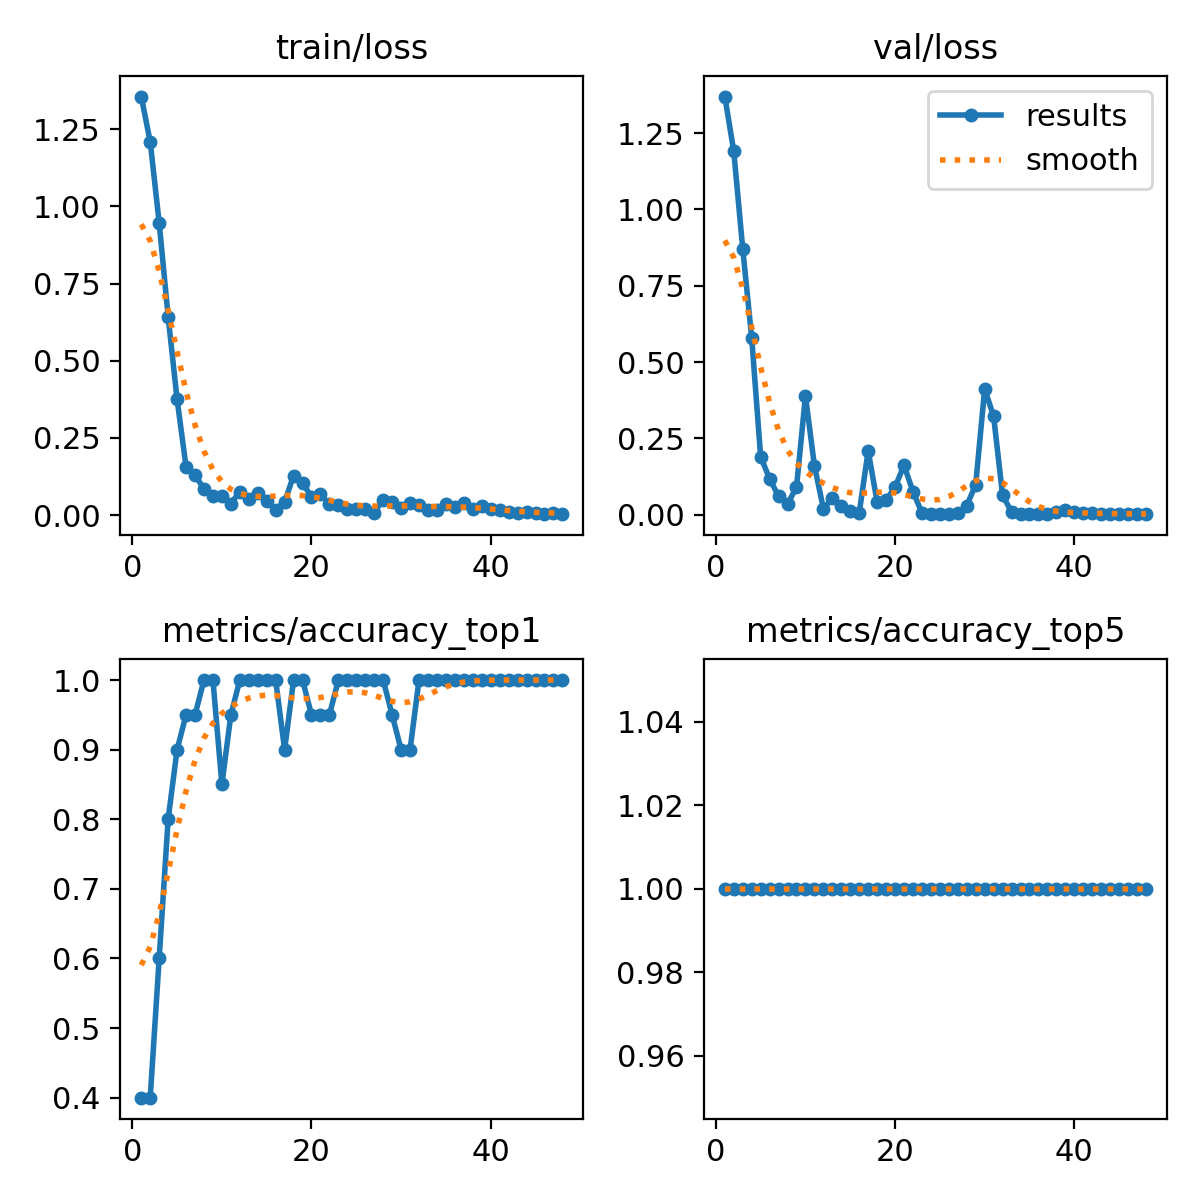

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/classify/train/results.png', width=600)

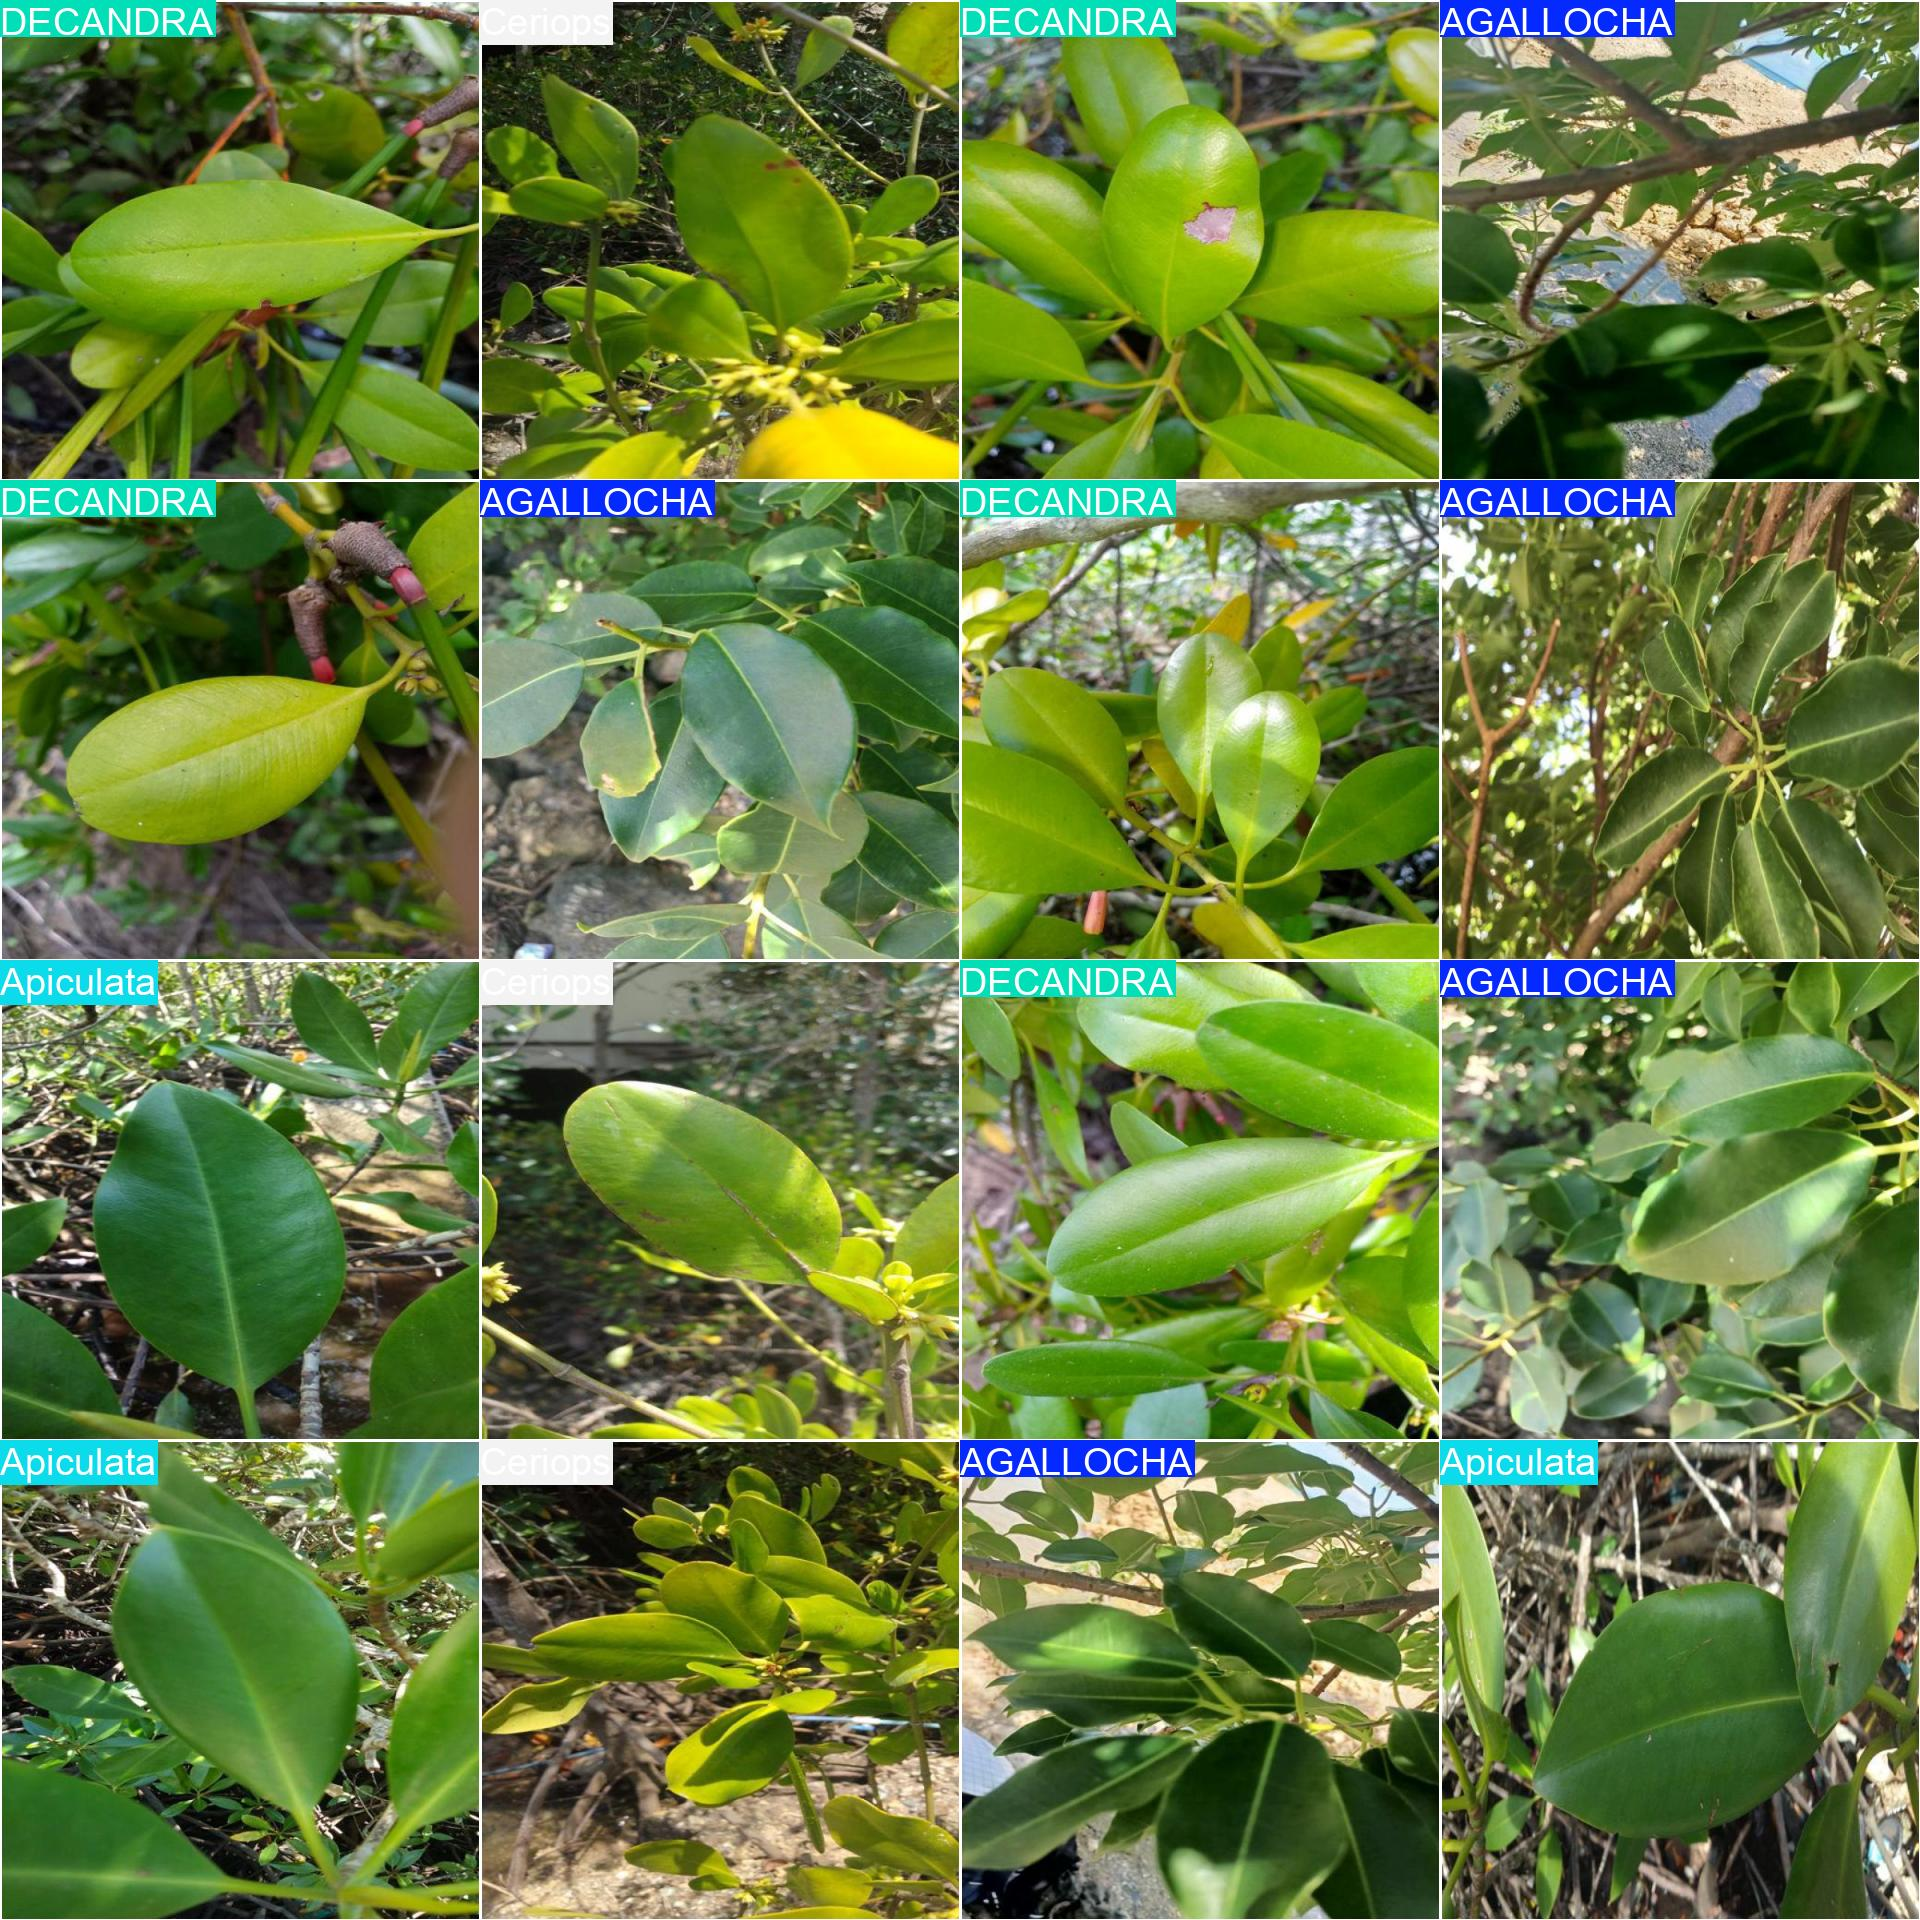

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/classify/train/val_batch0_pred.jpg', width=600)

In [ ]:
from google.colab import drive
import shutil
import os

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Define source and destination paths
source_folder = os.path.expanduser("/content/runs")  # Expand HOME environment variable
destination_folder = "/content/drive/MyDrive/COTS_TRAINING_MD/"  # Target folder in Google Drive

# Step 3: Create the destination folder if it doesn't exist
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)

# Step 4: Copy the folder to Google Drive
shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)

print(f"Output successfully moved to {destination_folder}!")

Mounted at /content/drive
Output successfully moved to /content/drive/MyDrive/COTS_TRAINING_MD/!


## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.97 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/CrownOfThorns_MD-1/valid/labels.cache... 99 images, 0 backgrounds, 0 corrupt: 100% 99/99 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 7/7 [00:02<00:00,  2.63it/s]
                   all         99        204      0.908      0.863      0.928      0.614
Speed: 4.0ms preprocess, 11.4ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.97 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/71 /content/CrownOfThorns_MD-1/test/images/032813_1068_jpg.rf.9360d49eeb4998dffb6907a317889ec2.jpg: 640x640 1 cots, 15.6ms
image 2/71 /content/CrownOfThorns_MD-1/test/images/032813_1076_jpg.rf.122e8444f7677911241dc8f574bde6d0.jpg: 640x640 2 cotss, 15.6ms
image 3/71 /content/CrownOfThorns_MD-1/test/images/101_jpg.rf.1d7ec542a7eb3c2d2246090620d71991.jpg: 640x640 1 cots, 15.5ms
image 4/71 /content/CrownOfThorns_MD-1/test/images/103_jpg.rf.c90f900186f5c4c82298875250970454.jpg: 640x640 1 cots, 15.5ms
image 5/71 /content/CrownOfThorns_MD-1/test/images/104_jpg.rf.cdc3b00cc6dce77b056aed6d3e97e6a7.jpg: 640x640 7 cotss, 15.5ms
image 6/71 /content/CrownOfThorns_MD-1/test/images/10_jpg.rf.aa2299f3280ad4569bc4f4fc9e41a836.jpg: 640x640 1 cots, 15.5ms
image 7/71 /content/CrownOfThorns_MD-1/test/images/112_jpg.rf.aae8db392bd9d896

**NOTE:** Let's take a look at few results.

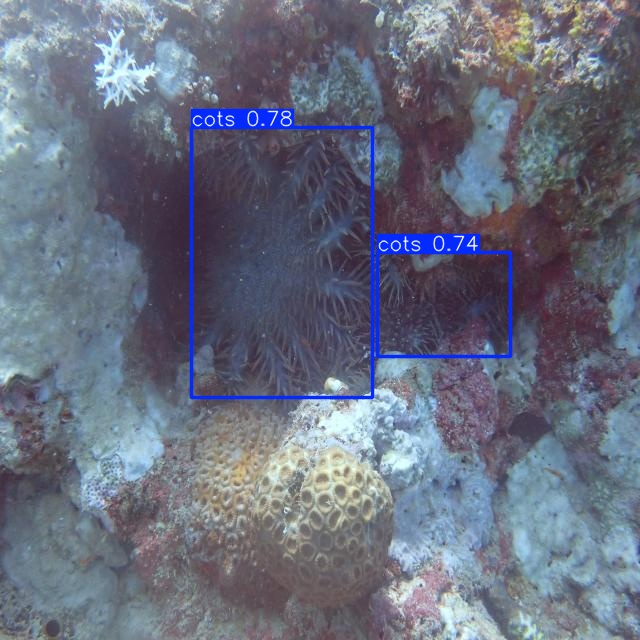

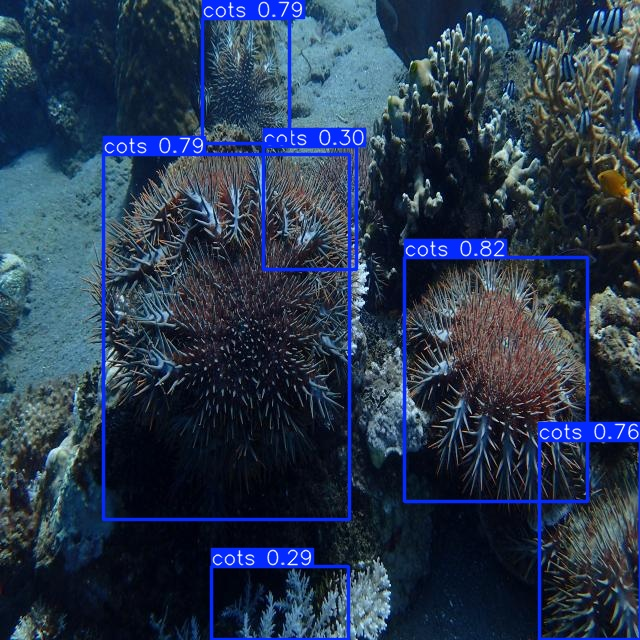

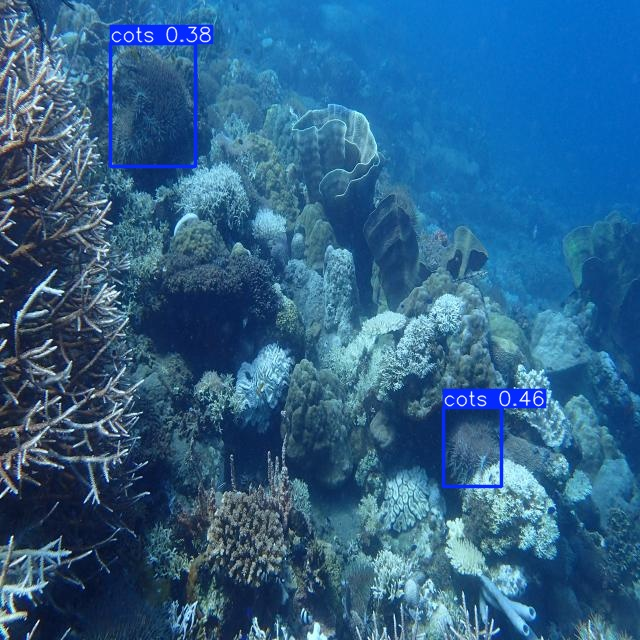

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [ ]:
project.version(dataset.version).deploy(model_type="yolov11", model_path=f"{HOME}/runs/detect/train/")

In [ ]:
!pip install inference

In [ ]:
import os, random, cv2
import supervision as sv
import IPython
import inference

model_id = project.id.split("/")[1] + "/" + dataset.version
model = inference.get_model(model_id, userdata.get('ROBOFLOW_API_KEY'))

# Location of test set images
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image = cv2.imread(os.path.join(test_set_loc, img_name))

    # Perform inference
    results = model.infer(image, confidence=0.4, overlap=30)[0]
    detections = sv.Detections.from_inference(results)

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import csv
from ultralytics import YOLO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Define paths
model_path = '/content/drive/MyDrive/COTS_TRAINING_MD/detect/train/weights/best.pt'  # Path to your model
testing_folder = '/content/drive/MyDrive/COTS_TRAINING/TEST2'  # Folder containing test images
output_folder = '/content/drive/MyDrive/COTS_TRAINING_MD/OUTPUT_DETECT2'  # Folder to save annotated images
csv_output_path = '/content/drive/MyDrive/COTS_TRAINING_MD/detection_counts_50images.csv'  # Path to save the CSV file

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Step 1: Load the model
try:
    print("Loading model...")
    model = YOLO(model_path)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

# Step 2: Process all images in the testing folder
results_data = []  # To store results for CSV

print("Processing images...")
for image_name in os.listdir(testing_folder):
    image_path = os.path.join(testing_folder, image_name)

    # Skip non-image files
    if not (image_name.endswith('.jpg') or image_name.endswith('.png')):
        continue

    try:
        print(f"Running inference on image: {image_name}")
        results = model(image_path)

        # Extract detections
        detections = results[0].boxes.data.cpu().numpy()  # Bounding boxes and scores

        # Filter for COT class (replace with your actual class ID)
        cot_class_id = 0  # Update this to the correct class ID
        cot_detections = [det for det in detections if det[-1] == cot_class_id]

        # Count detections
        cot_count = len(cot_detections)
        print(f'{image_name}: Number of Crown-of-Thorns detected: {cot_count}')

        # Save the annotated image
        annotated_image_array = results[0].plot()  # Generate annotated image
        annotated_image = Image.fromarray(np.uint8(annotated_image_array))  # Convert to PIL Image
        annotated_image_path = os.path.join(output_folder, f'annotated_{image_name}')
        annotated_image.save(annotated_image_path)

        # Append results to the data list
        results_data.append({'Image': image_name, 'COT_Count': cot_count})

    except Exception as e:
        print(f"Error processing {image_name}: {e}")

# Step 3: Save results to CSV
try:
    print(f"Saving results to CSV: {csv_output_path}")
    with open(csv_output_path, mode='w', newline='') as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=['Image', 'COT_Count'])
        writer.writeheader()
        writer.writerows(results_data)
    print("CSV file saved successfully!")
except Exception as e:
    print(f"Error saving CSV file: {e}")


Loading model...
Model loaded successfully!
Processing images...
Running inference on image: testIMG16.jpg

image 1/1 /content/drive/MyDrive/COTS_TRAINING/TEST2/testIMG16.jpg: 640x640 5 cotss, 15.6ms
Speed: 6.4ms preprocess, 15.6ms inference, 318.0ms postprocess per image at shape (1, 3, 640, 640)
testIMG16.jpg: Number of Crown-of-Thorns detected: 5
Running inference on image: testIMG34.jpg

image 1/1 /content/drive/MyDrive/COTS_TRAINING/TEST2/testIMG34.jpg: 640x640 2 cotss, 15.6ms
Speed: 2.6ms preprocess, 15.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
testIMG34.jpg: Number of Crown-of-Thorns detected: 2
Running inference on image: testIMG17.jpg

image 1/1 /content/drive/MyDrive/COTS_TRAINING/TEST2/testIMG17.jpg: 640x640 11 cotss, 15.6ms
Speed: 2.0ms preprocess, 15.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
testIMG17.jpg: Number of Crown-of-Thorns detected: 11
Running inference on image: testIMG28.jpg

image 1/1 /content/drive/MyDrive/

In [ ]:
import os
import csv
from ultralytics import YOLO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Define paths
model_path = '/content/drive/MyDrive/COTS_TRAINING_MD/detect/train/weights/best.pt'  # Path to your model
testing_folder = '/content/drive/MyDrive/COTS_TRAINING/TEST2'  # Folder containing test images
output_folder = '/content/drive/MyDrive/COTS_TRAINING_MD/OUTPUT_DETECT3'  # Folder to save annotated images
csv_output_path = '/content/drive/MyDrive/COTS_TRAINING_MD/detection_counts_v3_50images.csv'  # Path to save the CSV file

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)



# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Step 1: Load the model
try:
    print("Loading model...")
    model = YOLO(model_path)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

# Step 2: Process all images in the testing folder
results_data = []  # To store results for CSV

print("Processing images...")
for image_name in os.listdir(testing_folder):
    image_path = os.path.join(testing_folder, image_name)

    # Skip non-image files
    if not (image_name.endswith('.jpg') or image_name.endswith('.png')or image_name.endswith('.jpeg') or image_name.endswith('.webp')  ):
        continue

    try:
        print(f"Running inference on image: {image_name}")
        results = model(image_path)

        # Extract detections
        detections = results[0].boxes.data.cpu().numpy()  # Bounding boxes and scores

        # Filter for COT class (replace with your actual class ID)
        cot_class_id = 0  # Update this to the correct class ID
        cot_detections = [det for det in detections if det[-1] == cot_class_id]

        # Count detections
        cot_count = len(cot_detections)
        print(f'{image_name}: Number of Crown-of-Thorns detected: {cot_count}')

        # Save the annotated image
        annotated_image_array = results[0].plot()  # Generate annotated image
        annotated_image = Image.fromarray(np.uint8(annotated_image_array))  # Convert to PIL Image
        annotated_image_filename = f'annotated_{image_name}'
        annotated_image_path = os.path.join(output_folder, annotated_image_filename)
        annotated_image.save(annotated_image_path)

        # Append results to the data list
        results_data.append({
            'Image': image_name,
            'COT_Count': cot_count,
            'Annotated_Image': annotated_image_filename
        })

    except Exception as e:
        print(f"Error processing {image_name}: {e}")

# Step 3: Save results to CSV
try:
    print(f"Saving results to CSV: {csv_output_path}")
    with open(csv_output_path, mode='w', newline='') as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=['Image', 'COT_Count', 'Annotated_Image'])
        writer.writeheader()
        writer.writerows(results_data)
    print("CSV file saved successfully!")
except Exception as e:
    print(f"Error saving CSV file: {e}")


Loading model...
Model loaded successfully!
Processing images...
Running inference on image: testIMG16.jpg

image 1/1 /content/drive/MyDrive/COTS_TRAINING/TEST2/testIMG16.jpg: 640x640 5 cotss, 20.0ms
Speed: 2.8ms preprocess, 20.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
testIMG16.jpg: Number of Crown-of-Thorns detected: 5
Running inference on image: testIMG34.jpg

image 1/1 /content/drive/MyDrive/COTS_TRAINING/TEST2/testIMG34.jpg: 640x640 2 cotss, 15.7ms
Speed: 2.3ms preprocess, 15.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
testIMG34.jpg: Number of Crown-of-Thorns detected: 2
Running inference on image: testIMG17.jpg

image 1/1 /content/drive/MyDrive/COTS_TRAINING/TEST2/testIMG17.jpg: 640x640 11 cotss, 15.6ms
Speed: 3.2ms preprocess, 15.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
testIMG17.jpg: Number of Crown-of-Thorns detected: 11
Running inference on image: testIMG28.jpg

image 1/1 /content/drive/MyDrive/CO

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.